magh 13-handaling categorical data


In [8]:
import pandas as pd
df= pd.DataFrame(
    {
        "Eid":[101,102,103,104],
        "Name":["Ram","Shyam","Hari","Sita"],
        "Level":["Junior","Senior","Junior","Mid"]
    }
)
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Eid     4 non-null      int64 
 1   Name    4 non-null      object
 2   Level   4 non-null      object
dtypes: int64(1), object(2)
memory usage: 228.0+ bytes
None


,Eid,Name,Level
0,101,Ram,Junior
1,102,Shyam,Senior
2,103,Hari,Junior
3,104,Sita,Mid


In [9]:
#CONVERT label TO CATEGORY DATA TYPE
df["Level"]= df["Level"].astype('category')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   Eid     4 non-null      int64   
 1   Name    4 non-null      object  
 2   Level   4 non-null      category
dtypes: category(1), int64(1), object(1)
memory usage: 332.0+ bytes
None


In [10]:
df["Level"].cat

In [11]:
df["Level"]=df["Level"].cat.rename_categories(
    {
        "Junior":"Jr",
        "Senior":"Sr"
    }
)
print(df.head())

   Eid   Name Level
0  101    Ram    Jr
1  102  Shyam    Sr
2  103   Hari    Jr
3  104   Sita   Mid


In [13]:
df["Level_Code"]=df ["Level"].cat.codes
print(df.head())

   Eid   Name Level  Level_Code
0  101    Ram    Jr           0
1  102  Shyam    Sr           2
2  103   Hari    Jr           0
3  104   Sita   Mid           1


In [17]:
encoded = pd.get_dummies(df["Level"],prefix="Lev",dtype=int)
print(encoded)

   Lev_Jr  Lev_Mid  Lev_Sr
0       1        0       0
1       0        0       1
2       1        0       0
3       0        1       0


In [18]:
df_final= pd.concat([df,encoded],axis=1)
print(df_final.head())

   Eid   Name Level  Level_Code  Lev_Jr  Lev_Mid  Lev_Sr
0  101    Ram    Jr           0       1        0       0
1  102  Shyam    Sr           2       0        0       1
2  103   Hari    Jr           0       1        0       0
3  104   Sita   Mid           1       0        1       0


time 

In [23]:
df= pd.DataFrame({
    "Date":['2024-01-01','2024-01-02','2024-01-03','2024-01-01'],
    "Sales":[120,200,300,102]
})
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    4 non-null      object
 1   Sales   4 non-null      int64 
dtypes: int64(1), object(1)
memory usage: 196.0+ bytes
None


In [24]:
df["Date"]=pd.to_datetime(df["Date"])
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    4 non-null      datetime64[ns]
 1   Sales   4 non-null      int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 196.0 bytes
None


In [25]:
df= df.set_index("Date")
print(df.head())

            Sales
Date             
2024-01-01    120
2024-01-02    200
2024-01-03    300
2024-01-01    102


In [28]:
df["Year"]=df.index.year
df["Month"]=df.index.month
df['day']=df.index.day_name()
df['MonthNmae']=df.index.month_name()
print(df.head())

            Sales  Year  Month        day MonthNmae
Date                                               
2024-01-01    120  2024      1     Monday   January
2024-01-02    200  2024      1    Tuesday   January
2024-01-03    300  2024      1  Wednesday   January
2024-01-01    102  2024      1     Monday   January


In [35]:
df.loc['2024-01-01':'2024-01-03']

KeyError: 'Value based partial slicing on non-monotonic DatetimeIndexes with non-existing keys is not allowed.'

<Axes: xlabel='day'>

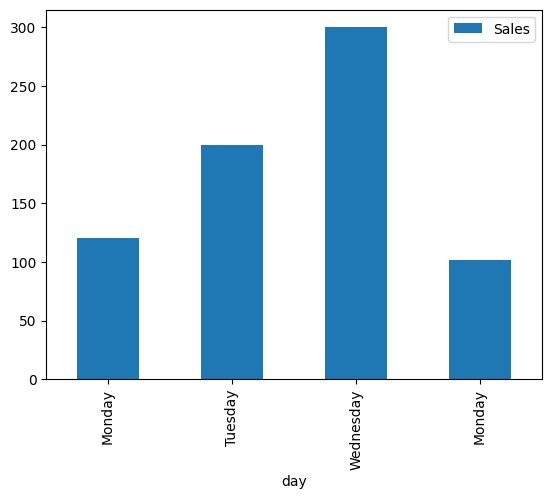

In [33]:
df.plot.bar(x='day',y='Sales')

In [36]:
df.to_csv('dates.csv')

In [39]:
new_df=pd.read_csv(
    'dates.csv',
    parse_dates=['Date'],
    index_col='Date'
)
new_df.head()

,Sales,Year,Month,day,MonthNmae
Date,,,,,
2024-01-01,120,2024,1,Monday,January
2024-01-02,200,2024,1,Tuesday,January
2024-01-03,300,2024,1,Wednesday,January
2024-01-01,102,2024,1,Monday,January


Feature transformation and scaling

In [43]:
#log transformation
import numpy as np
import pandas as pd 
x= pd.Series([0,1,10,100,1000])#1d obj
x_log = np.log1p(x)
print(x_log)

0    0.000000
1    0.693147
2    2.397895
3    4.615121
4    6.908755
dtype: float64


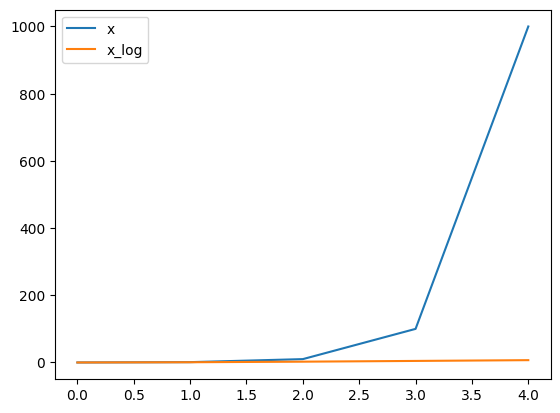

In [49]:
import matplotlib.pyplot as plt
plt.plot(x,label="x")
plt.plot(x_log,label="x_log")
plt.legend()


Power Transformation

In [ ]:
from sklearn.preprocessing import PowerTransformer
pt= PowerTransformer(method='yeo-johnson')

Normalization

In [56]:
from sklearn.preprocessing import MinMaxScaler
x=np.array([[100],[200],[800],[900],[1000]])
scaler=MinMaxScaler()
x_transforemed=scaler.fit_transform(x)
print(x_transforemed)

#error check it

[[0.        ]
 [0.11111111]
 [0.77777778]
 [0.88888889]
 [1.        ]]


In [ ]:
x=[100,200,800,900,1000]
min_value=min(x)
max_value=max(x)
for i in range(len(x)):
    